In [12]:
import supervision as sv
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Supervision versión: {sv.__version__}")

Supervision versión: 0.28.0


Imagen cargada: (374, 595, 3)


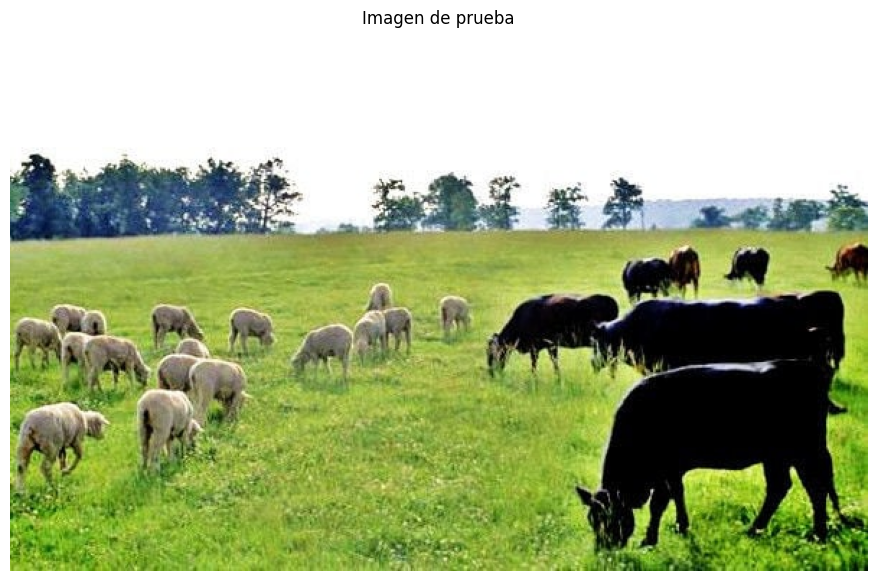

In [13]:
import urllib.request

Path("assets/fotos").mkdir(exist_ok=True)

urllib.request.urlretrieve(
    "https://bloximages.chicago2.vip.townnews.com/agupdate.com/content/tncms/assets/v3/editorial/b/26/b2607a2e-0451-11e8-8660-17c13bcc70e9/5a6e0a6170918.image.jpg",
    "assets/fotos/farm.jpg"
)

image = cv2.imread("assets/fotos/farm.jpg")
print(f"Imagen cargada: {image.shape}")
# image.shape → (alto, ancho, canales)
# Los canales son BGR en OpenCV (azul, verde, rojo) — no RGB como en matplotlib

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

In [14]:
model = YOLO("yolov8s.pt")
# nano, small, large...

In [15]:
results = model(image)[0]
# [0] toma el primer (y único) resultado — siempre necesario aunque proceses una sola imagen

detections = sv.Detections.from_ultralytics(results)
# Estandariza el output de YOLO


0: 416x640 13 sheeps, 7 cows, 446.4ms
Speed: 30.5ms preprocess, 446.4ms inference, 24.1ms postprocess per image at shape (1, 3, 416, 640)


In [16]:
print(f"Número de objetos detectados: {len(detections)}")

print(f"\n--- xyxy: coordenadas del bounding box ---")
print("Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]")
print(detections.xyxy)

print(f"\n--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---")
print(detections.confidence)

print(f"\n--- class_id: número de la categoría detectada ---")
print(detections.class_id)

print(f"\n--- Traducción de class_id a nombre ---")
for class_id in sorted(set(detections.class_id)):
    print(f"  Clase {class_id}: {results.names[class_id]}")

Número de objetos detectados: 20

--- xyxy: coordenadas del bounding box ---
Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]
[[     390.49      225.87      580.33      361.67]
 [     329.74      181.06      423.13      241.27]
 [     403.35      180.94      579.41       257.1]
 [     87.643      247.25      133.13      305.14]
 [     193.51      202.14       238.1      241.44]
 [     423.93       156.2      460.86      187.25]
 [     1.9408      257.07      53.619      322.55]
 [     494.91      148.56      527.15      177.12]
 [     456.38      147.52      479.43      184.81]
 [     50.014       209.7      97.494      250.71]
 [     150.97      191.09      184.32      225.39]
 [      566.1      145.83      594.84      173.87]
 [     297.47      182.69      320.79      216.55]
 [     122.73      225.98      165.14      274.57]
 [       1.11       197.6      37.376      235.65]
 [     236.86       190.7       279.7      228.89]
 [     98.095      188.41      135.41      219.92]
 [ 

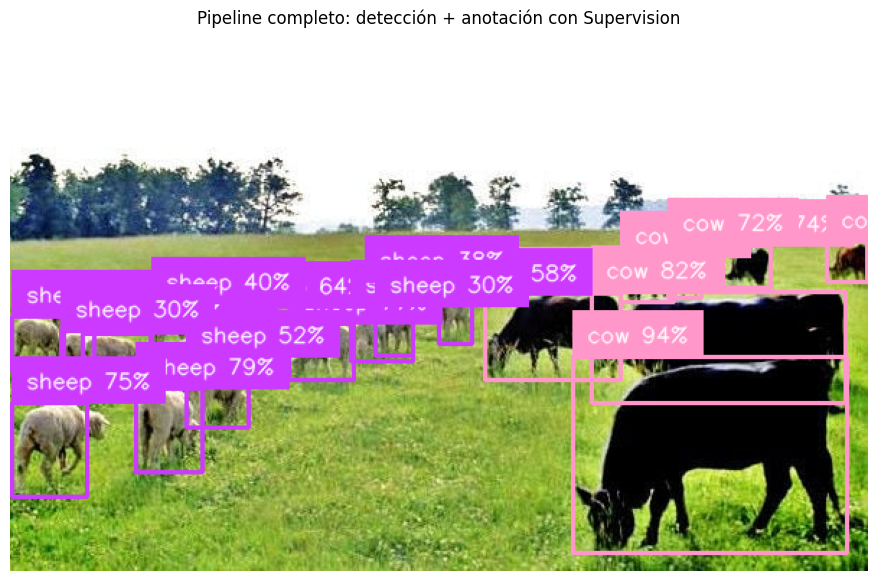

In [17]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"{results.names[class_id]} {conf:.0%}"
    for class_id, conf in zip(detections.class_id, detections.confidence)
]

# image.copy() es IMPORTANTE: evita modificar la imagen original
annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Pipeline completo: detección + anotación con Supervision")
plt.show()

In [18]:
results_estricto = model(image, conf=0.8)[0]
detections_estricto = sv.Detections.from_ultralytics(results_estricto)

print(f"Con conf=0.5 (por defecto): {len(detections)} objetos detectados")
print(f"Con conf=0.8 (estricto):    {len(detections_estricto)} objetos detectados")

# Modelo más estricto = Menos objetos detectados


0: 416x640 3 cows, 261.7ms
Speed: 6.0ms preprocess, 261.7ms inference, 3.0ms postprocess per image at shape (1, 3, 416, 640)
Con conf=0.5 (por defecto): 20 objetos detectados
Con conf=0.8 (estricto):    3 objetos detectados


In [19]:
primera = detections[0]

x1, y1, x2, y2 = primera.xyxy[0]
print(f"Primera detección:")
print(f"  Clase:    {results.names[primera.class_id[0]]}")
print(f"  Confianza: {primera.confidence[0]:.1%}")
print(f"  Posición:  esquina superior-izquierda ({x1:.0f}, {y1:.0f})")
print(f"             esquina inferior-derecha   ({x2:.0f}, {y2:.0f})")
print(f"  Tamaño:    {x2-x1:.0f} px de ancho × {y2-y1:.0f} px de alto")

# Primera detección del modelo: Vaca 

Primera detección:
  Clase:    cow
  Confianza: 94.0%
  Posición:  esquina superior-izquierda (390, 226)
             esquina inferior-derecha   (580, 362)
  Tamaño:    190 px de ancho × 136 px de alto


In [20]:
model_s = YOLO("yolov8s.pt") 
results_s = model_s(image)[0]
detections_s = sv.Detections.from_ultralytics(results_s)

print(f"yolov8n (nano):  {len(detections)} objetos")
print(f"yolov8s (small): {len(detections_s)} objetos")

# Pueden detectar los mismos objetos, más la confianza variará


0: 416x640 13 sheeps, 7 cows, 621.7ms
Speed: 5.3ms preprocess, 621.7ms inference, 6.4ms postprocess per image at shape (1, 3, 416, 640)
yolov8n (nano):  20 objetos
yolov8s (small): 20 objetos


In [21]:
import json

def detections_to_dict(detections, class_names=None):
    """Convierte sv.Detections a un dict JSON-compatible."""
    return {
        "xyxy":        detections.xyxy.tolist(),
        "confidence":  detections.confidence.tolist() if detections.confidence is not None else None,
        "class_id":    detections.class_id.tolist()   if detections.class_id   is not None else None,
        "class_names": [class_names[c] for c in detections.class_id]
                       if (class_names and detections.class_id is not None) else None,
    }

resultado = detections_to_dict(detections, class_names=results.names)

with open("assets/predicciones/predicciones.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print("Guardado: assets/predicciones/predicciones.json")
print(json.dumps(resultado, indent=2))

Guardado: assets/predicciones/predicciones.json
{
  "xyxy": [
    [
      390.4899597167969,
      225.87017822265625,
      580.3302612304688,
      361.6653747558594
    ],
    [
      329.7439270019531,
      181.0563201904297,
      423.13177490234375,
      241.2671661376953
    ],
    [
      403.354736328125,
      180.9371795654297,
      579.40771484375,
      257.10125732421875
    ],
    [
      87.64259338378906,
      247.2456817626953,
      133.1273956298828,
      305.1428527832031
    ],
    [
      193.51129150390625,
      202.14256286621094,
      238.09542846679688,
      241.43540954589844
    ],
    [
      423.934814453125,
      156.2049102783203,
      460.85833740234375,
      187.24600219726562
    ],
    [
      1.940773606300354,
      257.0700988769531,
      53.61883544921875,
      322.5525817871094
    ],
    [
      494.9052429199219,
      148.5635223388672,
      527.1513061523438,
      177.11790466308594
    ],
    [
      456.3822326660156,
     

In [ ]:
import json

def detections_to_dict(detections, class_names=None):
    """Convierte sv.Detections a un dict JSON-compatible."""
    return {
        "xyxy":        detections.xyxy.tolist(),
        "confidence":  detections.confidence.tolist() if detections.confidence is not None else None,
        "class_id":    detections.class_id.tolist()   if detections.class_id   is not None else None,
        "class_names": [class_names[c] for c in detections.class_id]
                       if (class_names and detections.class_id is not None) else None,
    }

resultado = detections_to_dict(detections, class_names=results.names)

with open("assets/predicciones/predicciones.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print("Guardado: assets/predicciones/predicciones.json")
print(json.dumps(resultado, indent=2))

Guardado: assets/predicciones.json
{
  "xyxy": [
    [
      390.4899597167969,
      225.87017822265625,
      580.3302612304688,
      361.6653747558594
    ],
    [
      329.7439270019531,
      181.0563201904297,
      423.13177490234375,
      241.2671661376953
    ],
    [
      403.354736328125,
      180.9371795654297,
      579.40771484375,
      257.10125732421875
    ],
    [
      87.64259338378906,
      247.2456817626953,
      133.1273956298828,
      305.1428527832031
    ],
    [
      193.51129150390625,
      202.14256286621094,
      238.09542846679688,
      241.43540954589844
    ],
    [
      423.934814453125,
      156.2049102783203,
      460.85833740234375,
      187.24600219726562
    ],
    [
      1.940773606300354,
      257.0700988769531,
      53.61883544921875,
      322.5525817871094
    ],
    [
      494.9052429199219,
      148.5635223388672,
      527.1513061523438,
      177.11790466308594
    ],
    [
      456.3822326660156,
      147.51600646